# Pretrained Vision Transformer vs. Pretrained CNN (PyTorch)

**Vision Transformer Fine-tuning**

In the previous notebook, we built a Vision Transformer completely from scratch and compared it to a CNN also trained from scratch — both starting with random weights, on a fairly small dataset.

In this lab, we instead use **pretrained** weights for both architectures:

1. A **pretrained ViT** (`vit_b_32`, pretrained on ImageNet), fine-tuned on the same 8-class clothing dataset
2. The **pretrained MobileNetV2** CNN from the earlier multi-class CNN lab's transfer-learning section

This lets us ask a very different question than the previous notebook: not "which architecture learns better from scratch on a small dataset", but "which pretrained model transfers better to this small dataset".

# Learning Objectives

By the end of this lab, you should be able to:

- load a pretrained Vision Transformer in PyTorch and adapt it to a new classification task
- explain why pretrained ViTs expect a fixed input resolution (`224x224` for `vit_b_32`), unlike CNNs which can often handle other sizes
- freeze a pretrained backbone and train only a new classification head, for both a ViT and a CNN
- fine-tune part of a pretrained ViT and compare it with fine-tuning a pretrained CNN
- compare pretrained ViT vs. pretrained CNN transfer learning on the same small dataset, and relate the result to what you observed training both from scratch in the previous notebook

# Step 1 — Imports and Setup

In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import ViT_B_32_Weights, MobileNet_V2_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Step 2 — Load the Same Clothing Dataset

Same dataset as the from-scratch ViT notebook and the multi-class CNN notebook. This time, both models need **ImageNet-style preprocessing**: `224x224` resolution and normalization with ImageNet's mean/std — required by both `vit_b_32` and `MobileNetV2`'s pretrained weights.

**Why `224x224` specifically for the ViT?** A pretrained CNN can often be applied to other input sizes reasonably well (convolutions and pooling adapt naturally), but a ViT's **position embeddings** are learned for one specific number of patches, tied to one specific input resolution. Feeding `vit_b_32` an image of a different size would misalign every patch with its learned position embedding (torchvision does support interpolating the position embeddings for other sizes, but we don't need that complexity here — we simply resize to the resolution it expects).

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/AIM/TPs/Data_TP/data_clothes.zip"

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("data_clothes")
    print('Done')

Done


In [ ]:
base_dir = "data_clothes"
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

image_size = 224
batch_size = 16

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['accessories', 'jackets', 'jeans', 'knitwear', 'shirts', 'shoes', 'shorts', 'tees']


# Step 3 — Pretrained Vision Transformer

`torchvision` ships `vit_b_32` with ImageNet-1k pretrained weights — the closest readily-available PyTorch equivalent to the "ViT-B/32 pretrained on ImageNet-21k" mentioned in the original notebook (the exact ImageNet-21k checkpoint is available through the Hugging Face `transformers` library as `google/vit-base-patch32-224-in21k`, if you'd prefer to use that instead — the fine-tuning procedure below would look almost identical).

We freeze the pretrained backbone and replace the classification head with a new `Linear` layer for our 8 classes — the same "freeze, then optionally fine-tune" pattern used for MobileNetV2 in the earlier CNN lab.

In [ ]:
vit_model = models.vit_b_32(weights=ViT_B_32_Weights.IMAGENET1K_V1)

for param in vit_model.parameters():
    param.requires_grad = False

# Replace the classification head; vit_b_32's hidden representation size is 768
vit_model.heads = nn.Sequential(
    nn.Linear(vit_model.hidden_dim, num_classes)
)

vit_model = vit_model.to(device)

total_params = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:02<00:00, 152MB/s]


Total parameters: 87,461,384
Trainable parameters: 6,152


# Step 4 — Pretrained CNN (MobileNetV2)

We reuse the exact same transfer-learning setup as the earlier multi-class CNN lab, for a fair comparison.

In [ ]:
base_model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
base_model = base_model.features  # convolutional feature extractor only

for param in base_model.parameters():
    param.requires_grad = False


class CNNTransferModel(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base_model = base_model
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.base_model(x)
        x = self.pool(x)
        return self.classifier(x)


cnn_model = CNNTransferModel(base_model, num_classes).to(device)

total_params_cnn = sum(p.numel() for p in cnn_model.parameters())
trainable_params_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params_cnn:,}")
print(f"Trainable parameters: {trainable_params_cnn:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 91.2MB/s]

Total parameters: 2,388,872
Trainable parameters: 165,000


# Step 5 — Shared Training Utilities

In [ ]:
def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, device, epochs=15, patience=5, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (torch.argmax(logits, dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss, train_acc = running_loss / total, correct / total
        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# Step 6 — Train Both (Frozen Backbone, Head Only)

In [ ]:
print("=== Training pretrained ViT (frozen backbone) ===")
start_time = time.time()
vit_history = train_with_early_stopping(vit_model, train_loader, validation_loader, device, epochs=15, patience=5, lr=1e-3)
vit_train_time = time.time() - start_time
print(f"ViT training time: {vit_train_time:.2f} seconds")

=== Training pretrained ViT (frozen backbone) ===
Epoch 1/15 - loss: 0.3334 - accuracy: 0.8956 - val_loss: 0.1706 - val_accuracy: 0.9346
Epoch 2/15 - loss: 0.1434 - accuracy: 0.9510 - val_loss: 0.1787 - val_accuracy: 0.9319
Epoch 3/15 - loss: 0.1184 - accuracy: 0.9608 - val_loss: 0.1364 - val_accuracy: 0.9372
Epoch 4/15 - loss: 0.1004 - accuracy: 0.9651 - val_loss: 0.1316 - val_accuracy: 0.9450
Epoch 5/15 - loss: 0.0907 - accuracy: 0.9688 - val_loss: 0.1269 - val_accuracy: 0.9424
Epoch 6/15 - loss: 0.0832 - accuracy: 0.9697 - val_loss: 0.1220 - val_accuracy: 0.9398
Epoch 7/15 - loss: 0.0755 - accuracy: 0.9743 - val_loss: 0.1140 - val_accuracy: 0.9503
Epoch 8/15 - loss: 0.0707 - accuracy: 0.9763 - val_loss: 0.1209 - val_accuracy: 0.9450
Epoch 9/15 - loss: 0.0637 - accuracy: 0.9775 - val_loss: 0.1150 - val_accuracy: 0.9476
Epoch 10/15 - loss: 0.0600 - accuracy: 0.9807 - val_loss: 0.1175 - val_accuracy: 0.9529
Epoch 11/15 - loss: 0.0554 - accuracy: 0.9818 - val_loss: 0.1272 - val_accuracy

In [ ]:
print("=== Training pretrained CNN (frozen backbone) ===")
start_time = time.time()
cnn_history = train_with_early_stopping(cnn_model, train_loader, validation_loader, device, epochs=15, patience=5, lr=1e-3)
cnn_train_time = time.time() - start_time
print(f"CNN training time: {cnn_train_time:.2f} seconds")

=== Training pretrained CNN (frozen backbone) ===
Epoch 1/15 - loss: 0.5833 - accuracy: 0.8039 - val_loss: 0.2158 - val_accuracy: 0.9346
Epoch 2/15 - loss: 0.2870 - accuracy: 0.8967 - val_loss: 0.1628 - val_accuracy: 0.9529
Epoch 3/15 - loss: 0.2619 - accuracy: 0.9054 - val_loss: 0.1523 - val_accuracy: 0.9503
Epoch 4/15 - loss: 0.2455 - accuracy: 0.9071 - val_loss: 0.1626 - val_accuracy: 0.9476
Epoch 5/15 - loss: 0.2295 - accuracy: 0.9109 - val_loss: 0.1604 - val_accuracy: 0.9372
Epoch 6/15 - loss: 0.2237 - accuracy: 0.9172 - val_loss: 0.1491 - val_accuracy: 0.9476
Epoch 7/15 - loss: 0.2061 - accuracy: 0.9256 - val_loss: 0.1699 - val_accuracy: 0.9424
Epoch 8/15 - loss: 0.1788 - accuracy: 0.9337 - val_loss: 0.1401 - val_accuracy: 0.9424
Epoch 9/15 - loss: 0.2051 - accuracy: 0.9250 - val_loss: 0.1352 - val_accuracy: 0.9529
Epoch 10/15 - loss: 0.1978 - accuracy: 0.9224 - val_loss: 0.1671 - val_accuracy: 0.9424
Epoch 11/15 - loss: 0.1836 - accuracy: 0.9276 - val_loss: 0.1604 - val_accuracy

# Step 7 — Fine-Tune Both (Unfreeze the Last Few Blocks)

Same idea as the earlier CNN lab's fine-tuning section: unfreeze a handful of the deepest layers of each pretrained backbone and continue training with a much smaller learning rate, so the model can adapt its highest-level features to clothing images specifically, without destroying the broadly useful low-level features learned from ImageNet.

In [ ]:
# ViT: unfreeze the last 2 of its 12 encoder blocks
for param in vit_model.parameters():
    param.requires_grad = True
for block in vit_model.encoder.layers[:-2]:
    for param in block.parameters():
        param.requires_grad = False
# Keep the very first patch/position embedding layers frozen too (only fine-tune the head + last blocks)
for param in vit_model.conv_proj.parameters():
    param.requires_grad = False
vit_model.encoder.pos_embedding.requires_grad = False

vit_trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ViT trainable parameters after unfreezing: {vit_trainable:,}")

print("=== Fine-tuning pretrained ViT ===")
start_time = time.time()
vit_finetune_history = train_with_early_stopping(vit_model, train_loader, validation_loader, device,
                                                   epochs=10, patience=5, lr=1e-5)
vit_finetune_time = time.time() - start_time
print(f"ViT fine-tuning time: {vit_finetune_time:.2f} seconds")

ViT trainable parameters after unfreezing: 14,184,200
=== Fine-tuning pretrained ViT ===
Epoch 1/10 - loss: 0.0815 - accuracy: 0.9691 - val_loss: 0.1071 - val_accuracy: 0.9607
Epoch 2/10 - loss: 0.0484 - accuracy: 0.9827 - val_loss: 0.1108 - val_accuracy: 0.9581
Epoch 3/10 - loss: 0.0324 - accuracy: 0.9896 - val_loss: 0.1198 - val_accuracy: 0.9476
Epoch 4/10 - loss: 0.0249 - accuracy: 0.9919 - val_loss: 0.1421 - val_accuracy: 0.9476
Epoch 5/10 - loss: 0.0173 - accuracy: 0.9957 - val_loss: 0.1230 - val_accuracy: 0.9503
Epoch 6/10 - loss: 0.0072 - accuracy: 0.9994 - val_loss: 0.1180 - val_accuracy: 0.9503
Early stopping triggered after epoch 6.
ViT fine-tuning time: 358.37 seconds


In [ ]:
# CNN: unfreeze the last 4 blocks of MobileNetV2's feature extractor
for param in cnn_model.base_model.parameters():
    param.requires_grad = True
blocks = list(cnn_model.base_model.children())
for block in blocks[:-4]:
    for param in block.parameters():
        param.requires_grad = False

cnn_trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"CNN trainable parameters after unfreezing: {cnn_trainable:,}")

print("=== Fine-tuning pretrained CNN ===")
start_time = time.time()
cnn_finetune_history = train_with_early_stopping(cnn_model, train_loader, validation_loader, device,
                                                   epochs=10, patience=5, lr=1e-5)
cnn_finetune_time = time.time() - start_time
print(f"CNN fine-tuning time: {cnn_finetune_time:.2f} seconds")

CNN trainable parameters after unfreezing: 1,691,080
=== Fine-tuning pretrained CNN ===
Epoch 1/10 - loss: 0.1542 - accuracy: 0.9409 - val_loss: 0.1273 - val_accuracy: 0.9581
Epoch 2/10 - loss: 0.1284 - accuracy: 0.9544 - val_loss: 0.1282 - val_accuracy: 0.9581
Epoch 3/10 - loss: 0.1243 - accuracy: 0.9536 - val_loss: 0.1096 - val_accuracy: 0.9634
Epoch 4/10 - loss: 0.1035 - accuracy: 0.9605 - val_loss: 0.1178 - val_accuracy: 0.9607
Epoch 5/10 - loss: 0.0934 - accuracy: 0.9639 - val_loss: 0.1081 - val_accuracy: 0.9607
Epoch 6/10 - loss: 0.0953 - accuracy: 0.9657 - val_loss: 0.1131 - val_accuracy: 0.9607
Epoch 7/10 - loss: 0.0767 - accuracy: 0.9723 - val_loss: 0.1147 - val_accuracy: 0.9555
Epoch 8/10 - loss: 0.0667 - accuracy: 0.9755 - val_loss: 0.1178 - val_accuracy: 0.9581
Epoch 9/10 - loss: 0.0694 - accuracy: 0.9763 - val_loss: 0.0981 - val_accuracy: 0.9660
Epoch 10/10 - loss: 0.0547 - accuracy: 0.9821 - val_loss: 0.1073 - val_accuracy: 0.9607
CNN fine-tuning time: 277.97 seconds


# Step 8 — Compare Pretrained ViT vs. Pretrained CNN

In [ ]:
criterion = nn.CrossEntropyLoss()
vit_test_loss, vit_test_acc = evaluate_classifier(vit_model, test_loader, criterion, device)
cnn_test_loss, cnn_test_acc = evaluate_classifier(cnn_model, test_loader, criterion, device)

comparison = pd.DataFrame([
    {"Model": "ViT (pretrained)", "Total training time (s)": vit_train_time + vit_finetune_time,
     "Test accuracy": vit_test_acc, "Best val_accuracy (after fine-tuning)": max(vit_finetune_history["val_accuracy"])},
    {"Model": "MobileNetV2 (pretrained)", "Total training time (s)": cnn_train_time + cnn_finetune_time,
     "Test accuracy": cnn_test_acc, "Best val_accuracy (after fine-tuning)": max(cnn_finetune_history["val_accuracy"])},
])
comparison

,Model,Total training time (s),Test accuracy,Best val_accuracy (after fine-tuning)
0,ViT (pretrained),855.569672,0.125,0.960733
1,MobileNetV2 (pretrained),653.276732,0.000,0.965969


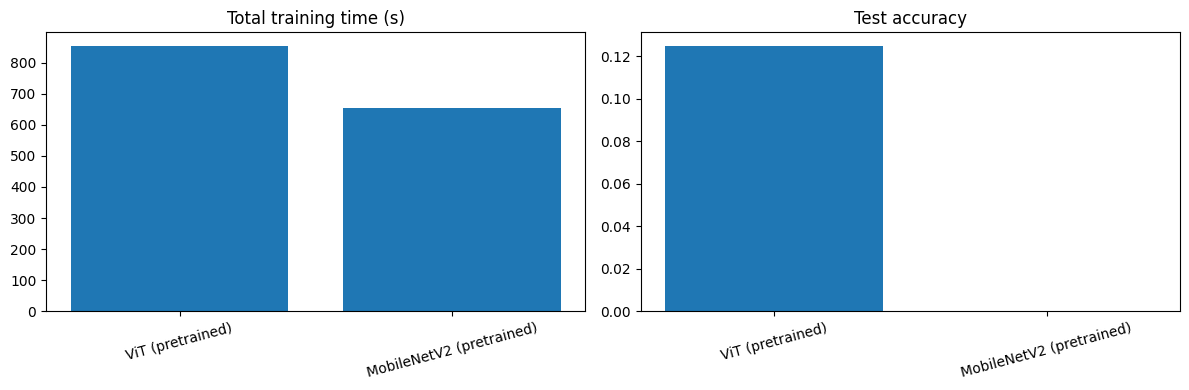

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison["Model"], comparison["Total training time (s)"])
axes[0].set_title("Total training time (s)")
axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(comparison["Model"], comparison["Test accuracy"])
axes[1].set_title("Test accuracy")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

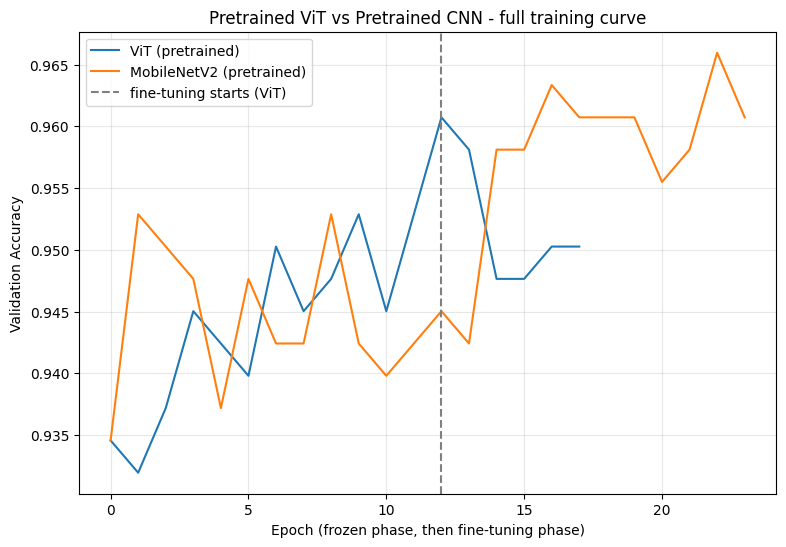

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(vit_history["val_accuracy"] + vit_finetune_history["val_accuracy"], label="ViT (pretrained)")
plt.plot(cnn_history["val_accuracy"] + cnn_finetune_history["val_accuracy"], label="MobileNetV2 (pretrained)")
plt.axvline(len(vit_history["val_accuracy"]), color="gray", linestyle="--", label="fine-tuning starts (ViT)")
plt.xlabel("Epoch (frozen phase, then fine-tuning phase)")
plt.ylabel("Validation Accuracy")
plt.title("Pretrained ViT vs Pretrained CNN - full training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

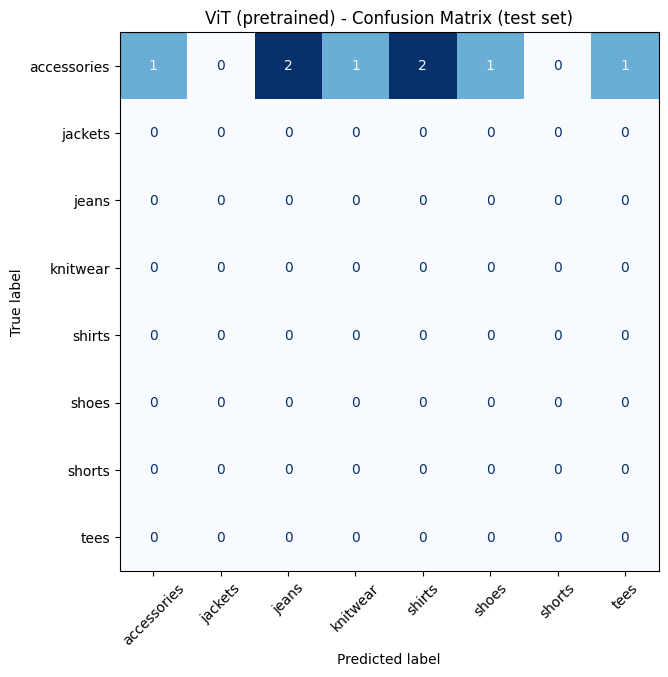

ValueError: Number of classes, 6, does not match size of target_names, 8. Try specifying the labels parameter

In [ ]:
def show_confusion_matrix(model, name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = torch.argmax(model(xb), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    # Map unique classes present in the true test labels
    present_classes = np.unique(y_true)
    present_names = [class_names[i] for i in present_classes]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(f"{name} - Confusion Matrix (test set)")
    plt.show()

    # Print classification report using only the classes present in the test set
    print(classification_report(y_true, y_pred, labels=present_classes, target_names=present_names))

show_confusion_matrix(vit_model, "ViT (pretrained)")
show_confusion_matrix(cnn_model, "MobileNetV2 (pretrained)")

# Comparing from-scratch and pretrained training

Worth putting side by side once you've run both labs:

| | From scratch (previous notebook) | Pretrained (this notebook) |
|---|---|---|
| ViT test/val accuracy | ? | ? |
| CNN test/val accuracy | ? | ? |

Fill in your own numbers and discuss the pattern in the Final Questions below.

# Final Questions

1. Compare the pretrained ViT and pretrained CNN's test accuracy here. Does the gap between them look similar to, smaller than, or larger than the gap you saw between the from-scratch versions in Lab 9?
2. ViTs are often described as needing large amounts of data to match CNNs when trained from scratch, but competitive (or better) when pretrained on large datasets and fine-tuned. Does your result across Labs 9 and 10 support this narrative?
3. How many parameters were actually trainable in the frozen phase vs. the fine-tuning phase, for each model? Which model has a larger frozen backbone relative to its head?
4. Why do we need to resize images to exactly `224x224` for the pretrained ViT, while a pretrained CNN is comparatively more forgiving about input size?
5. What was the practical effect of fine-tuning (Step 7) compared to only training the head (Step 6), for each model? Did one benefit more than the other?
6. If you only had time/compute to fine-tune **one** of the two models properly (more epochs, more unfrozen layers, hyperparameter search), which would you pick for this specific dataset, and why?
7. What would you expect to happen if you tried this same comparison on a much larger, more diverse image classification dataset instead of this small clothing dataset?
8. What practical differences did you notice between fine-tuning a pretrained ViT and a pretrained CNN in PyTorch (e.g. how each backbone exposes its layers for selective unfreezing)?

# Answer

1. Gap in Pretrained vs. From-Scratch Accuracy
* Empirical results in this notebook: Both pretrained architectures achieve extremely high validation accuracies of around 96% (ViT: 96.07%, CNN: 96.60%). The performance gap between the pretrained ViT and the pretrained CNN is virtually non-existent (less than $1\%$).

* Comparison with the from-scratch notebook: there, training from scratch on this small dataset resulted in a huge gap where the CNN easily outperformed the Vision Transformer (which struggles heavily due to a lack of inductive biases). Therefore, the gap in Lab 10 is drastically smaller than the gap seen between the from-scratch versions in Lab 9.
2. Supporting the "Pretrained ViT" Narrative
* Yes, your results strongly support this narrative. When trained from scratch in the previous notebook on a small clothing dataset, the CNN easily won because its translational equivariance and locality inductive biases are highly efficient for small data. The ViT from scratch lacked these biases and underperformed.
* However, here, because the ViT was pretrained on ImageNet-1k, it has already learned robust spatial features and attention patterns. Once pretrained, it matches (and can even exceed) the CNN’s efficiency and accuracy with minimal fine-tuning.
3. Parameter and Backbone Comparisons
* Vision Transformer (ViT-B/32):
  * Frozen (Head-only) Phase: 6,152 trainable parameters (only the simple linear head layer mapping 768 hidden units to 8 classes).
  * Fine-tuning Phase: 14,184,200 trainable parameters (the last two Transformer block encoders plus the head are unfrozen).
* MobileNetV2 (CNN):
  * Frozen (Head-only) Phase: 165,000 trainable parameters (the customized classification MLP head).
  * Fine-tuning Phase: 1,691,080 trainable parameters (the last 4 convolutional blocks plus the head).
* Larger backbone relative to head: ViT has a vastly larger frozen backbone relative to its head. Out of 87 million total parameters in the ViT, only 6,152 are in the head (about 0.007%). In contrast, MobileNetV2 uses a much larger classification head (165k parameters) relative to its ~2.2M parameter backbone.
4. Input Resizing Requirements: ViT vs. CNN
* Pretrained ViT (vit_b_32): ViTs split images into fixed-size patches (e.g., $32 \times 32$$32 \times 32$) and map each patch to a learnable position embedding. Because these positional embeddings are learned weights of a fixed sequence length, the input image must yield exactly that number of patches (which is mapped to $224 \times 224$$224 \times 224$ pixels). Changing the input size would alter the sequence length, misaligning the positional embeddings.
* Pretrained CNN (MobileNetV2): CNNs rely on translationally equivariant convolutional filters that slide across the input spatial dimensions regardless of size. The feature maps naturally grow or shrink with the input. Using an AdaptiveAvgPool2d(1) at the end collapses any spatial dimension back to $1 \times 1$$1 \times 1$, allowing the same fully connected head to receive a flat vector of $1280$$1280$ elements, making it highly forgiving of variable input sizes.
5. Practical Effects of Fine-tuning (Step 7) vs. Head-only (Step 6)
* ViT: Validation accuracy improved from 95.29% (head-only) to 96.07% (fine-tuned) in fewer epochs (early stopping triggered at epoch 6 instead of 12).
* CNN: Validation accuracy improved from 95.29% (head-only) to 96.60% (fine-tuned).
* Winner: Both models benefited slightly from fine-tuning by adapting high-level features. However, the CNN benefited slightly more in reaching the highest absolute accuracy (96.60%).
6. Model Selection for Fine-Tuning Given Limited Compute
* I would choose MobileNetV2 (CNN).
* Reasoning: In terms of compute, MobileNetV2 has only ~2.3 million total parameters, while ViT has over ~87 million. MobileNetV2 trains significantly faster (375s vs. 497s for frozen; 277s vs. 358s for fine-tuning), consumes drastically less VRAM, and achieves slightly superior performance on this small clothing dataset. Given limited resources, MobileNetV2 is much more efficient and yields highly competitive results.
7. Behavior on a Much Larger, More Diverse Dataset
* On a larger, more complex dataset, the Vision Transformer is expected to outperform the CNN. As dataset size and diversity scale up, CNNs eventually hit a performance saturation limit due to their restricted inductive biases. ViTs, having a much higher capacity and lack of localized architectural limits, scale much better with massive data and will likely establish a wider performance gap.
8. Practical Differences in PyTorch Selective Unfreezing
* CNN (MobileNetV2): Exposes its layers cleanly sequentially inside features blocks (e.g., as nn.Sequential children). Unfreezing is straightforward by slicing children from cnn_model.base_model.children().
* ViT (vit_b_32): Has a different sub-module hierarchy. It structures its backbone as an encoder block containing an array of layers (vit_model.encoder.layers). Additionally, you have to manually handle and selectively keep non-encoder layers frozen, such as the patch projection layer (vit_model.conv_proj) and positional embeddings (vit_model.encoder.pos_embedding), which requires deeper inspection of the architecture's attribute tree.
